# 📊 Cross-Platform Analysis — TikTok vs Instagram

**@aroaxinping · Período: 24 Feb – 24 Mar 2026**

Análisis comparativo de rendimiento entre TikTok e Instagram: mismo creador, mismo período, dos algoritmos completamente distintos.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

BASE = Path('..')
tt = pd.read_csv(BASE / 'data/tiktok/videos_engagement.csv')
ig = pd.read_csv(BASE / 'data/instagram/reels_metricas.csv')
ig = ig[ig['visualizaciones'] > 0].copy()

TT_FOLLOWERS = 30_000
IG_FOLLOWERS = 8_728

print(f'TikTok: {len(tt)} vídeos | Instagram: {len(ig)} reels')

TikTok: 10 vídeos | Instagram: 30 reels


## 1. KPIs Globales

In [2]:
kpis = pd.DataFrame({
    'Métrica': [
        'Posts analizados', 'Vistas totales', 'Engagement Rate medio (%)',
        'Save Rate medio (%)', 'Share Rate medio (%)',
        'Seguidores ganados', 'Follower Rate/1K vistas'
    ],
    'TikTok': [
        len(tt),
        f"{tt['views'].sum():,.0f}",
        f"{tt['engagement_rate_pct'].mean():.2f}%",
        f"{tt['save_rate_pct'].mean():.2f}%",
        f"{tt['share_rate_pct'].mean():.2f}%",
        f"{tt['new_followers'].sum():,.0f}",
        f"{(tt['new_followers'].sum() / tt['views'].sum() * 1000):.3f}"
    ],
    'Instagram': [
        len(ig),
        f"{ig['visualizaciones'].sum():,.0f}",
        f"{ig['engagement_rate'].mean():.2f}%",
        f"{ig['save_rate'].mean():.2f}%",
        f"{ig['share_rate'].mean():.2f}%",
        f"{ig['seguidores_ganados'].sum():,.0f}",
        f"{(ig['seguidores_ganados'].sum() / ig['visualizaciones'].sum() * 1000):.3f}"
    ]
})

display(kpis.style.set_caption('KPIs comparativos — 24 Feb al 24 Mar 2026'))

,Métrica,TikTok,Instagram
0,Posts analizados,10,30
1,Vistas totales,"2,592,000","7,269,352"
2,Engagement Rate medio (%),18.48%,12.19%
3,Save Rate medio (%),1.24%,0.94%
4,Share Rate medio (%),1.91%,1.26%
5,Seguidores ganados,"2,536","7,682"
6,Follower Rate/1K vistas,0.978,1.057


## 2. Visualizaciones comparativas


### KPIs Comparativos


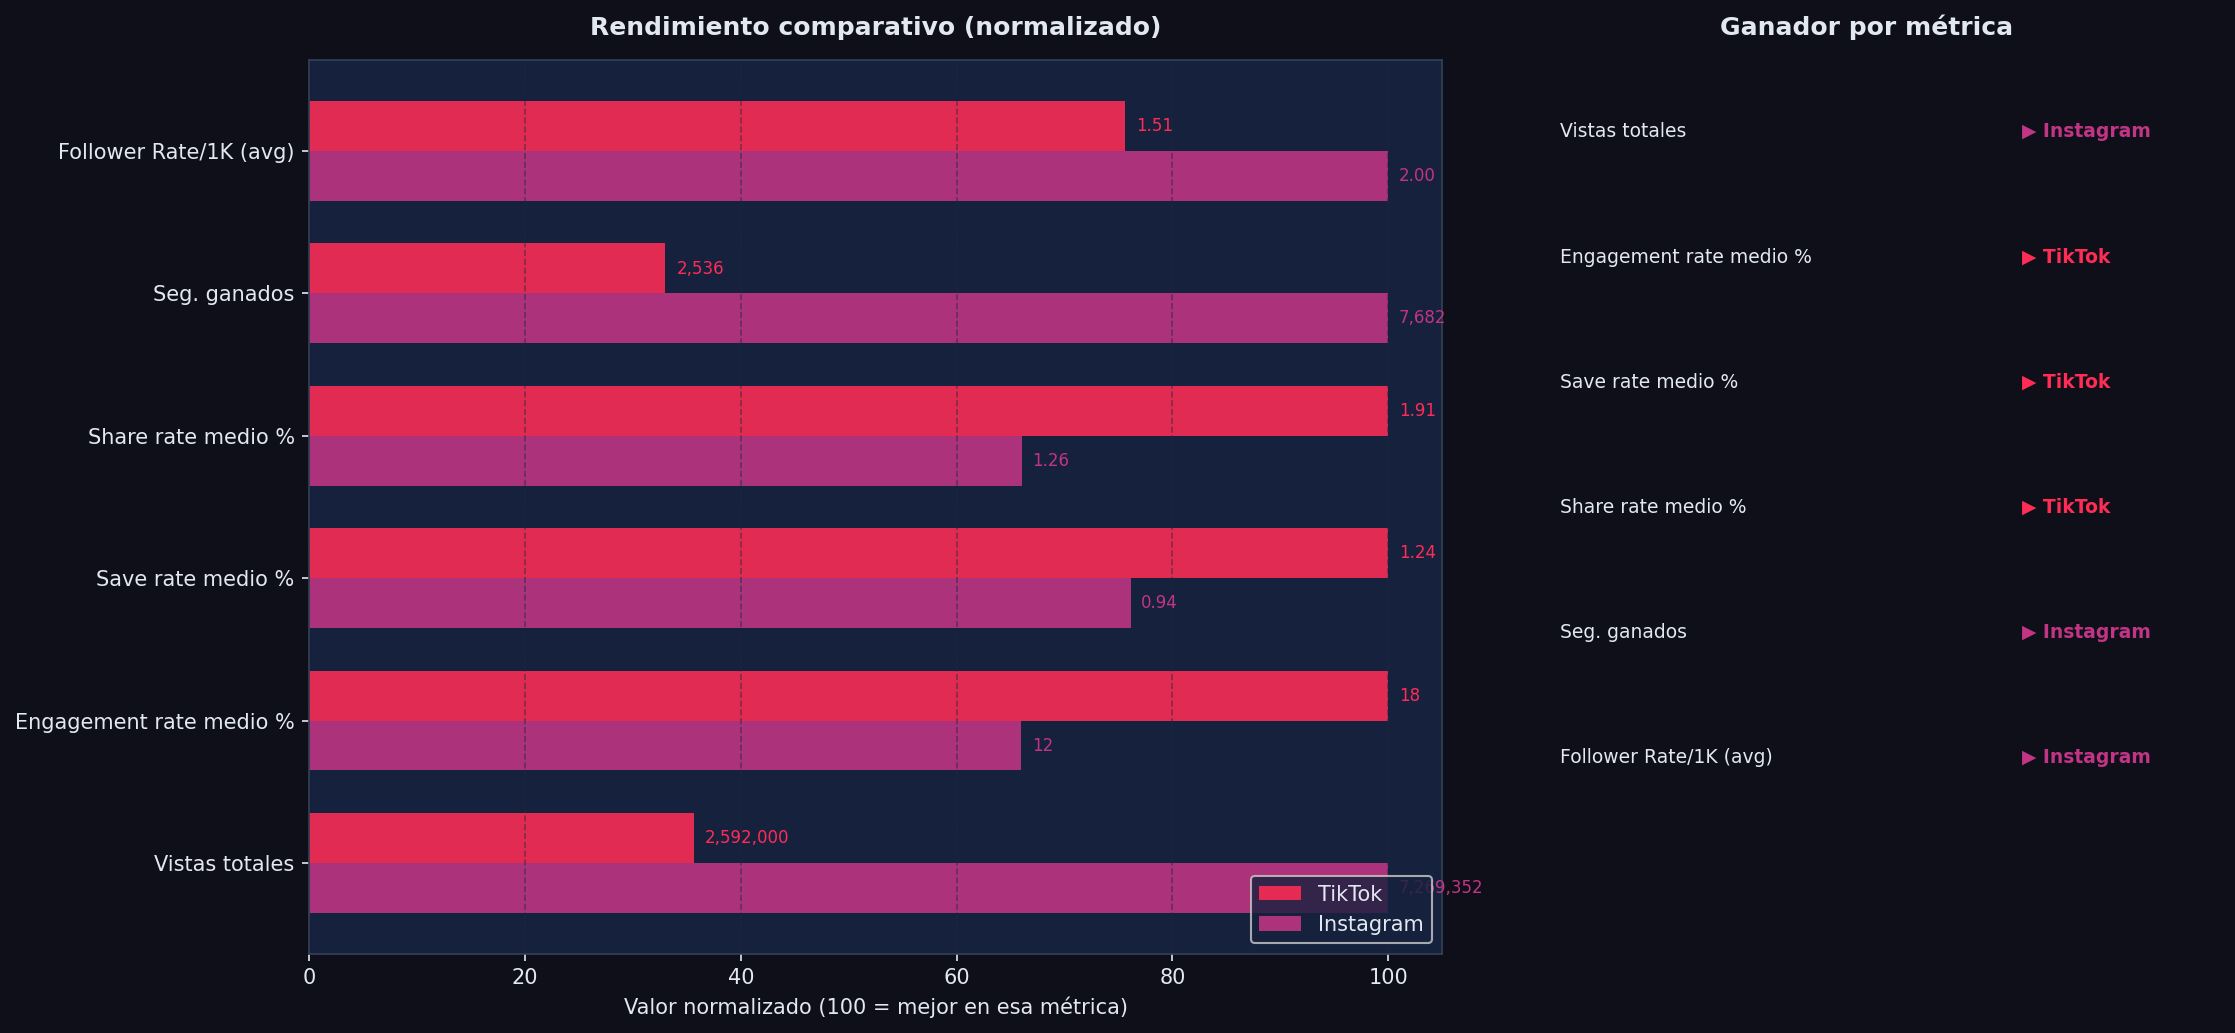


### Distribución Engagement Rate


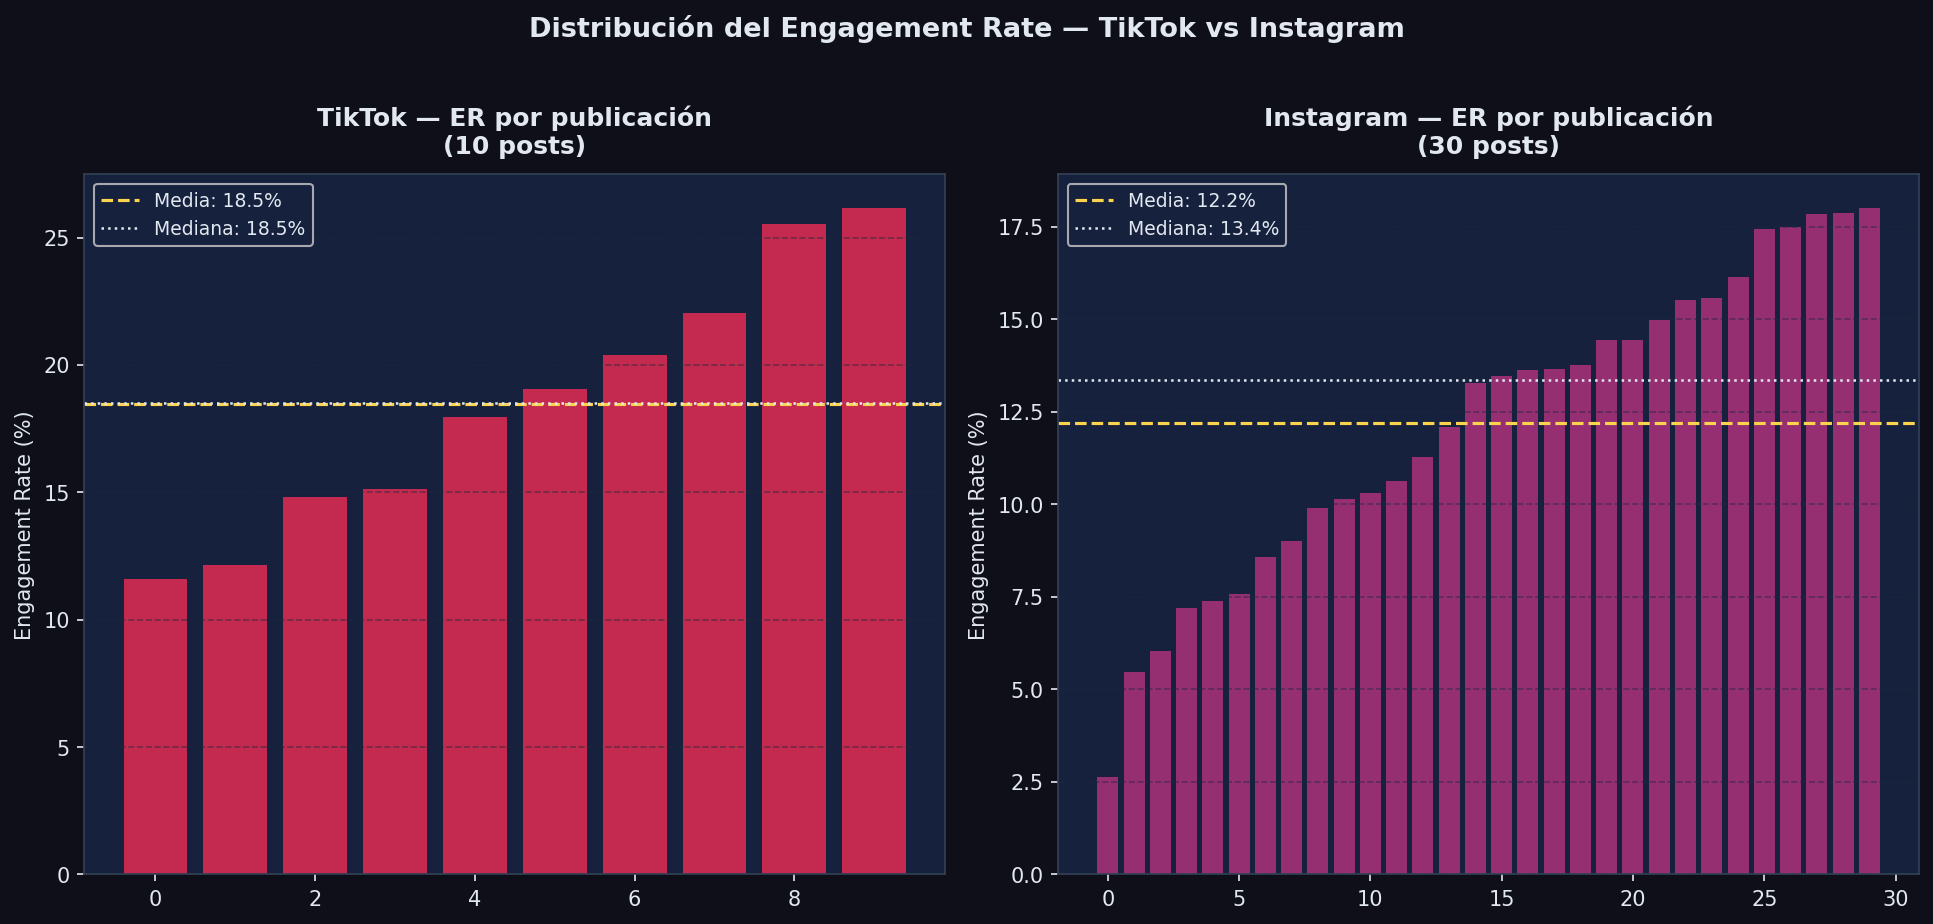


### Follower Conversion Rate/1K


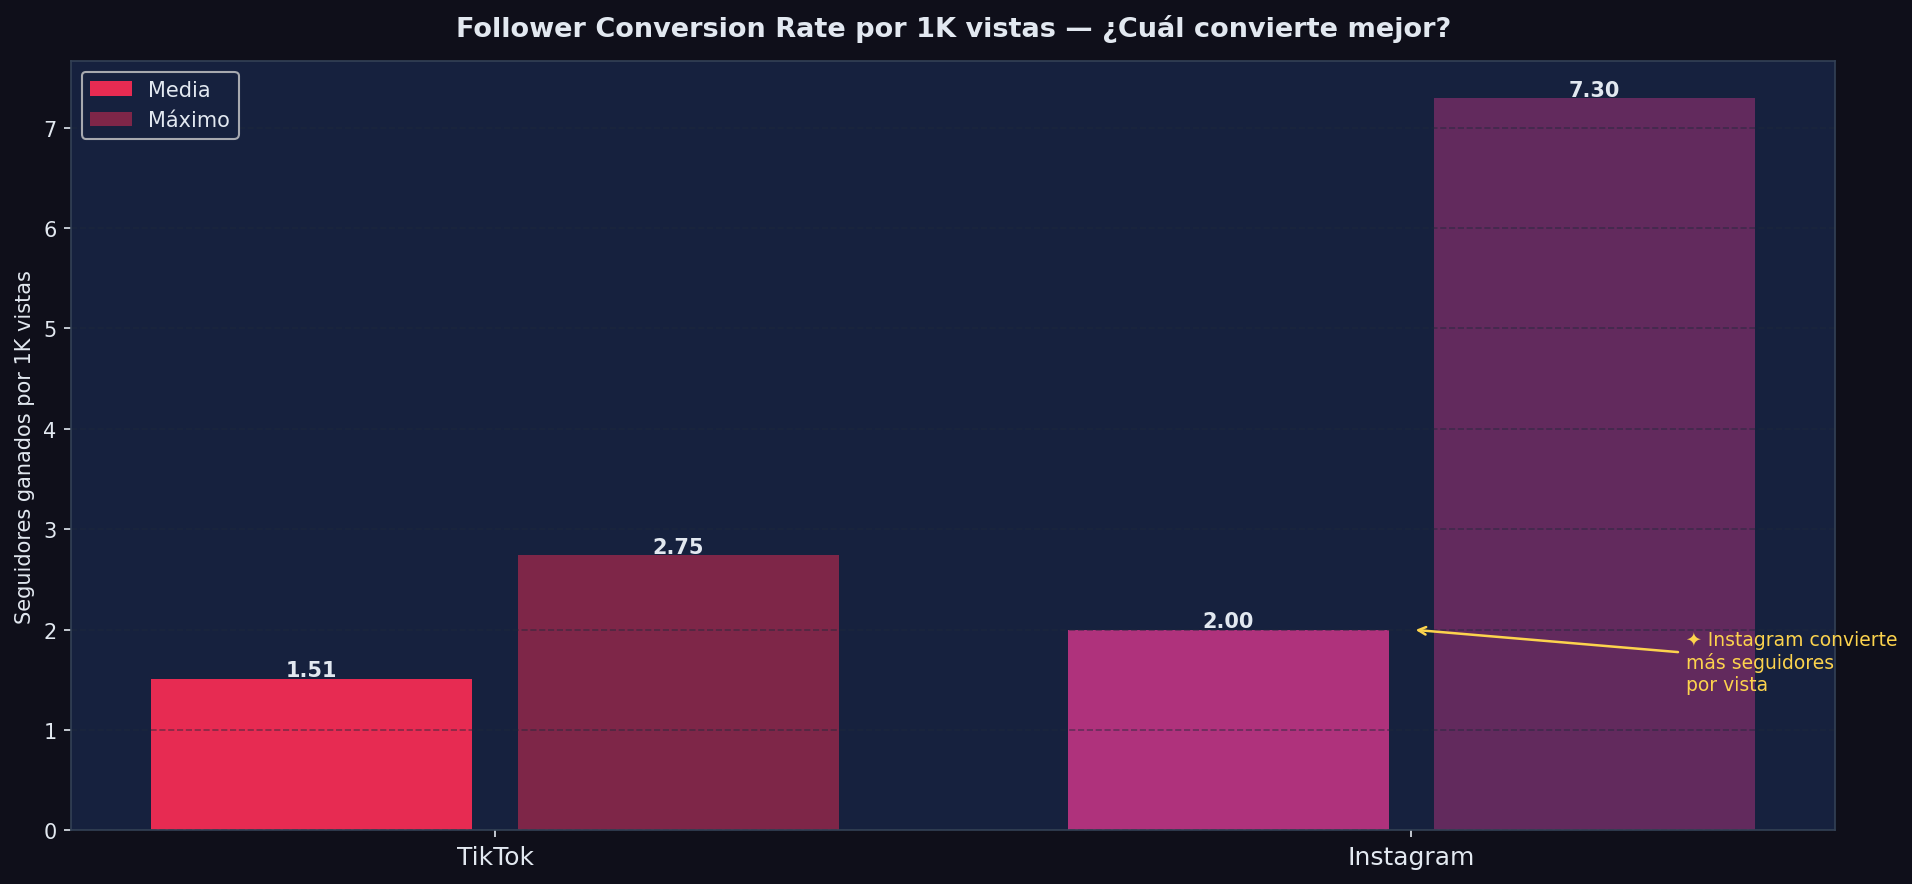


### Save Rate


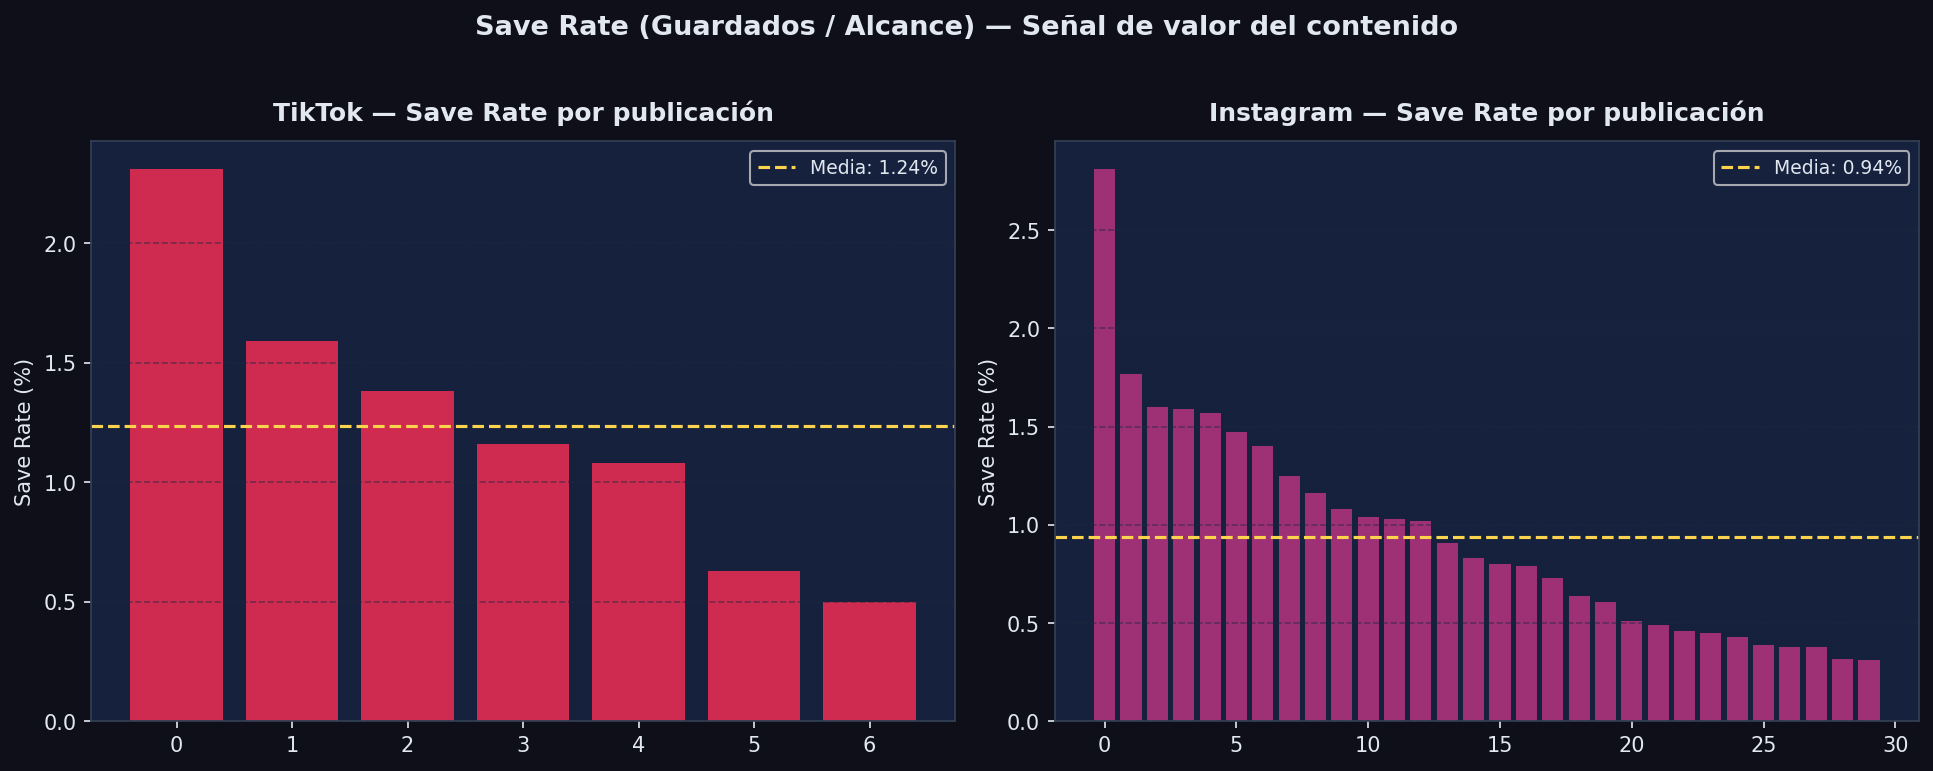


### Share Rate


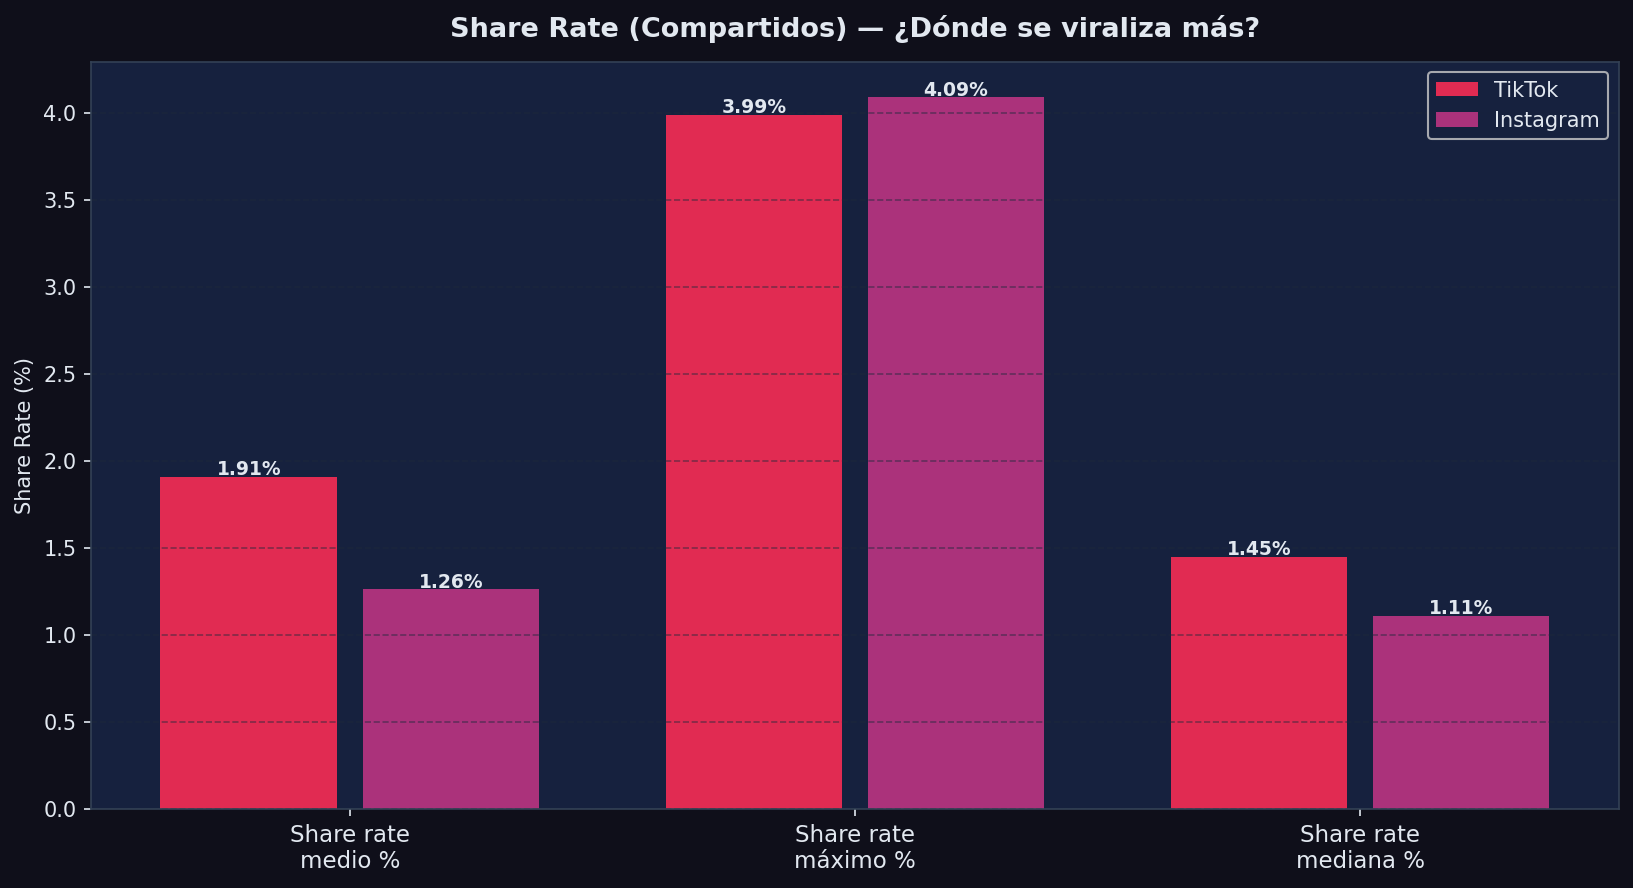


### Rendimiento por Temática


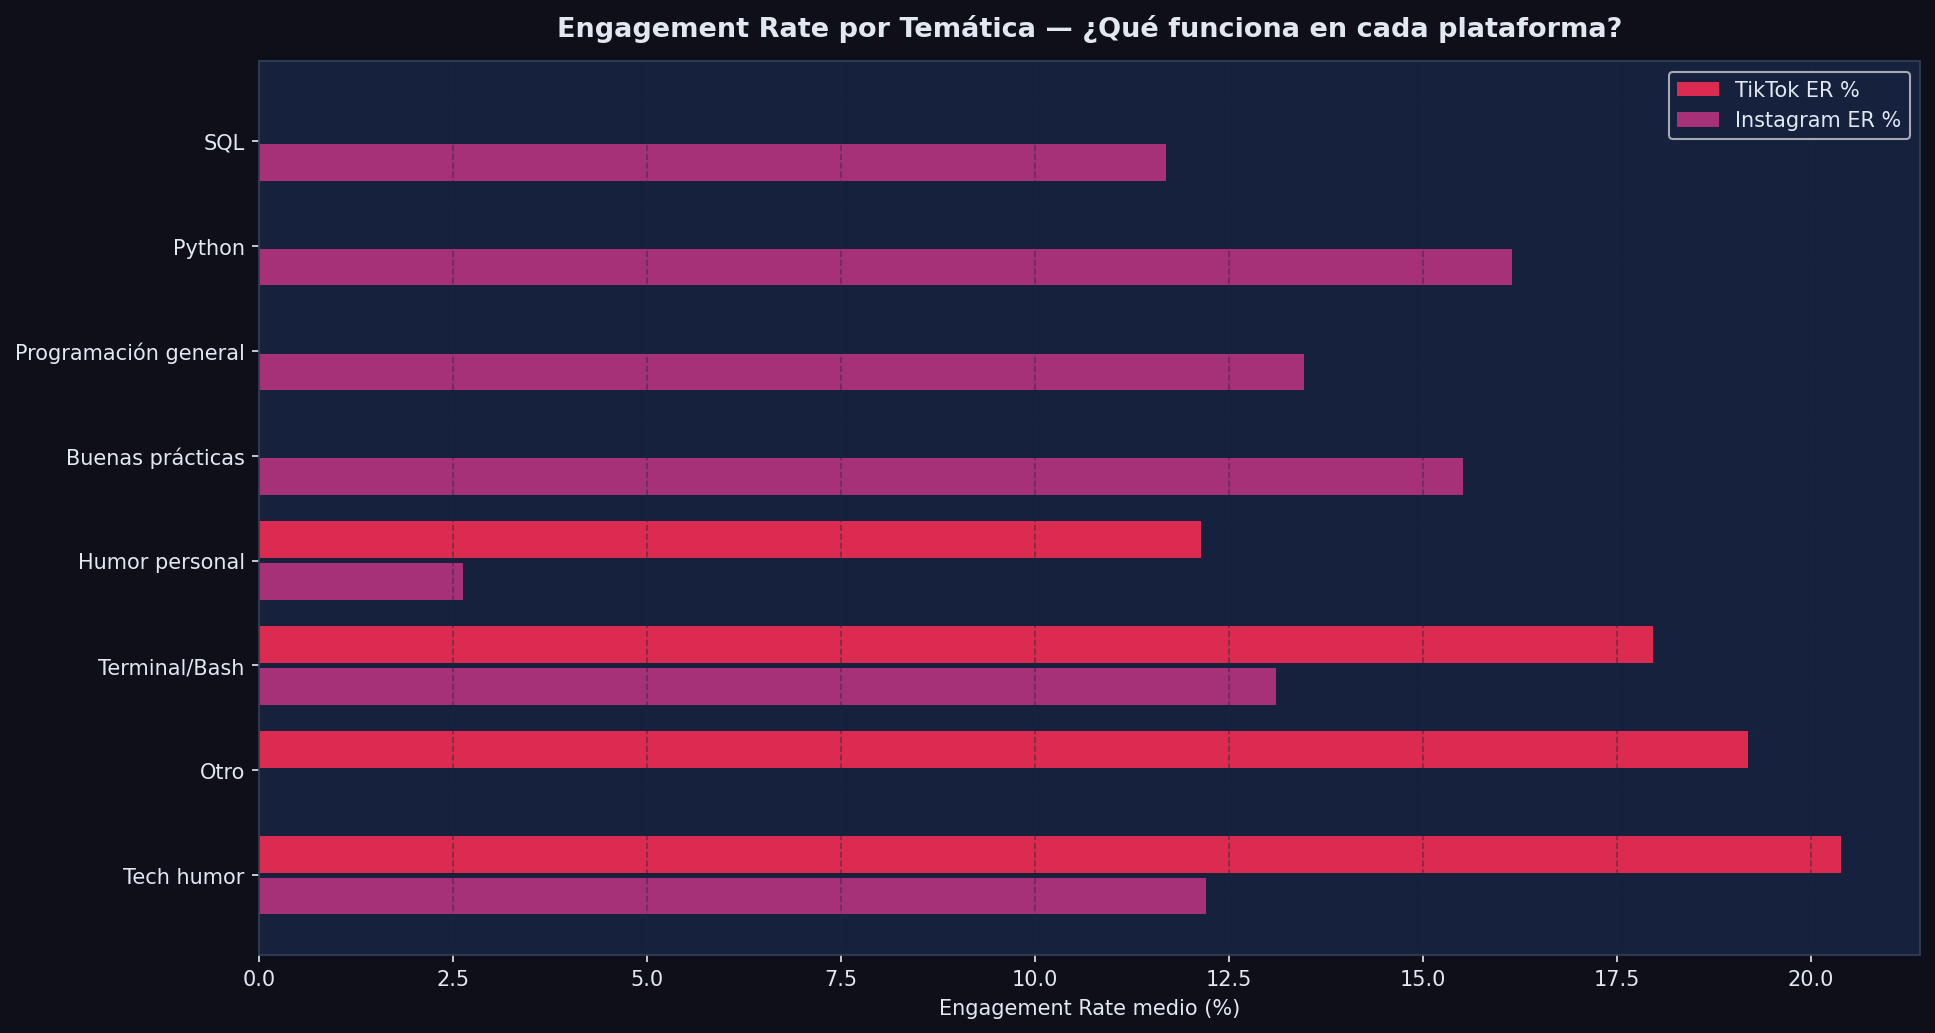


### Passive vs Active


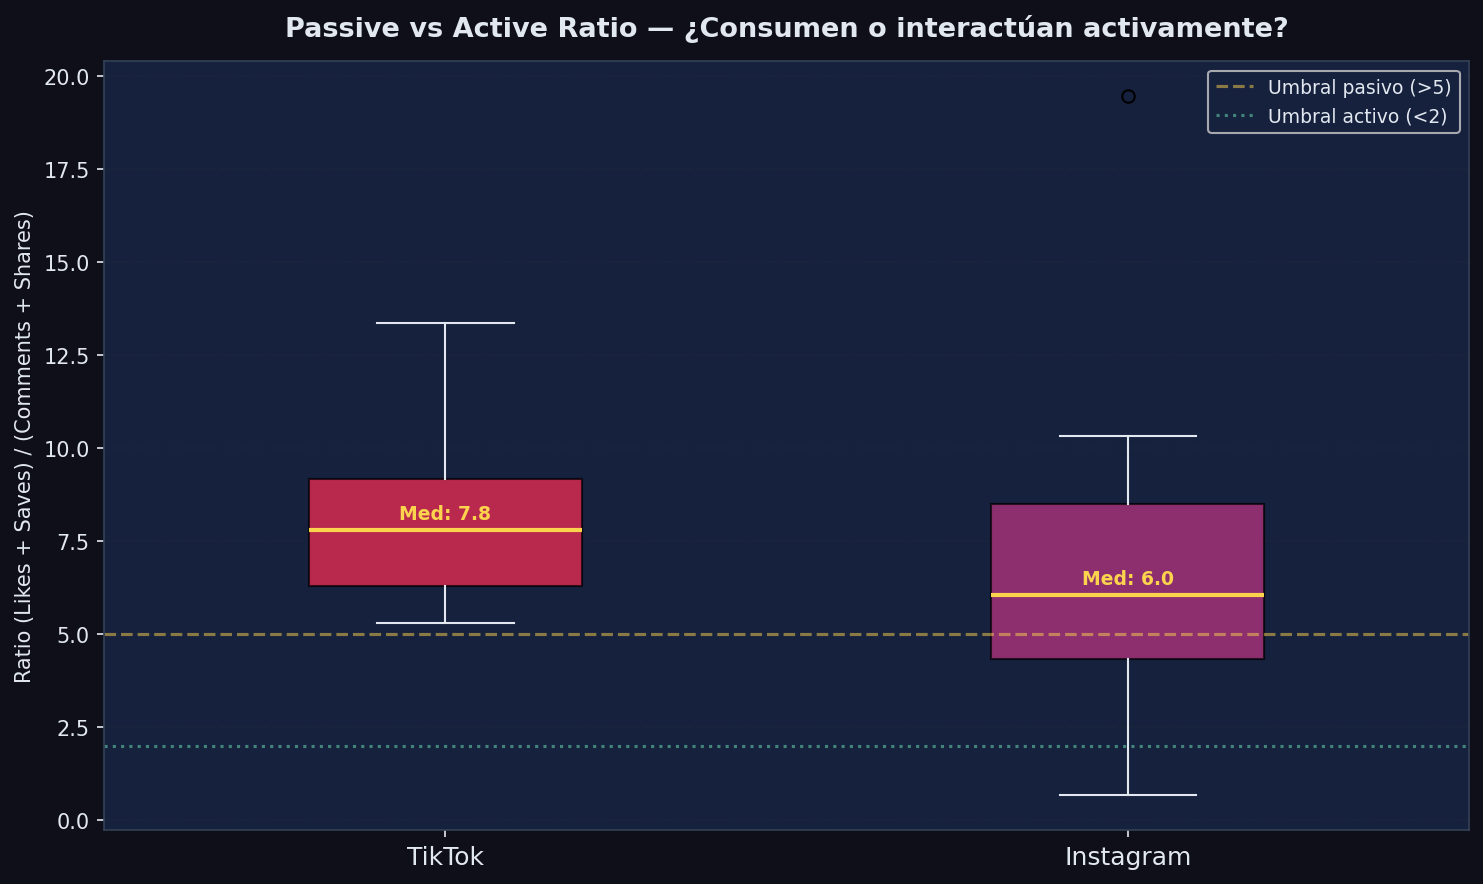


### Scorecard Ejecutivo


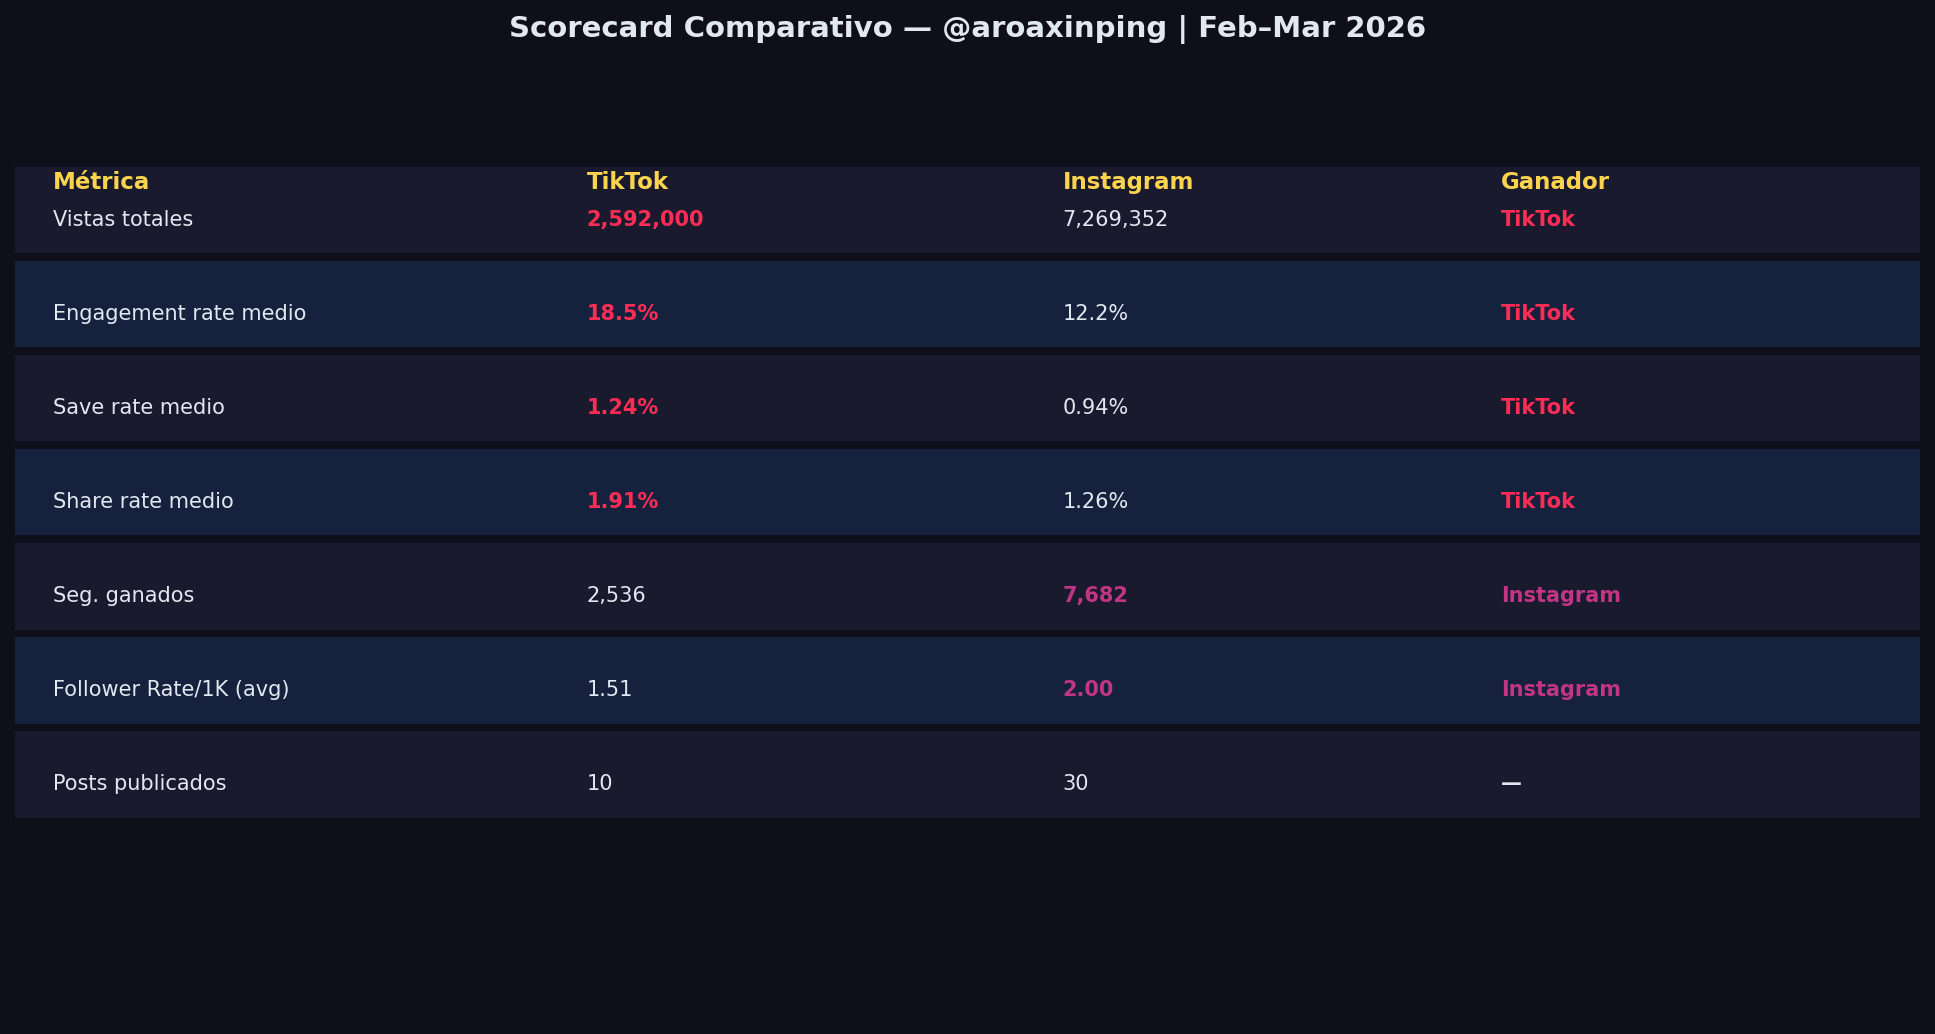

In [3]:
visuals = sorted((BASE / 'visuals').glob('*.png'))
titles = [
    'KPIs Comparativos', 'Distribución Engagement Rate',
    'Follower Conversion Rate/1K', 'Save Rate',
    'Share Rate', 'Rendimiento por Temática',
    'Passive vs Active', 'Scorecard Ejecutivo'
]

from IPython.display import Image, display as ipy_display

for path, title in zip(visuals, titles):
    print(f'\n### {title}')
    ipy_display(Image(str(path), width=900))

## 3. Engagement Rate por post — distribución detallada

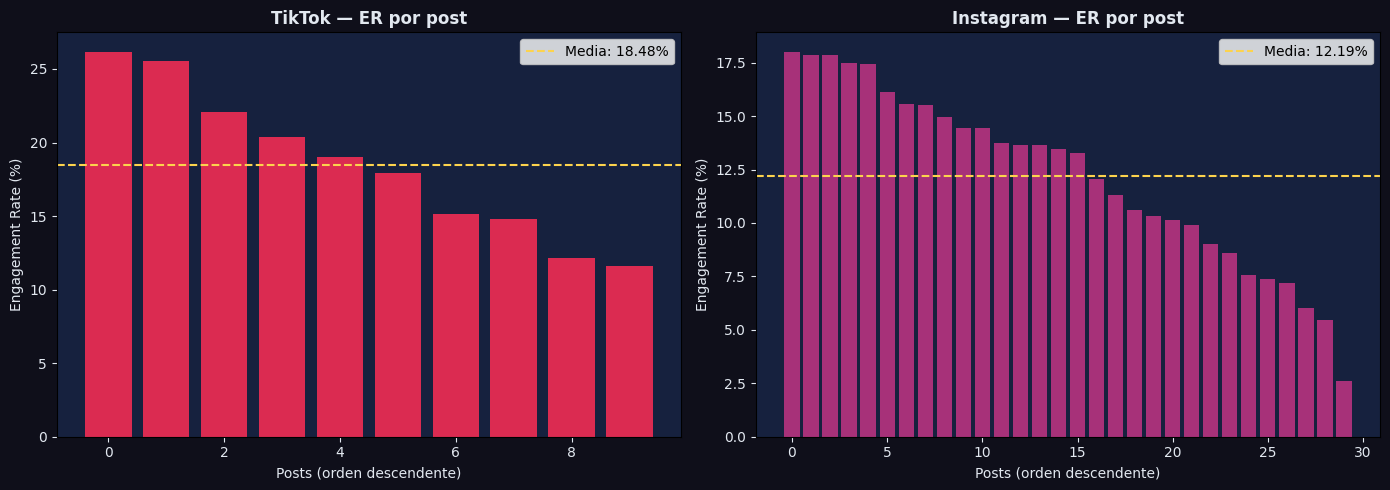

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0F0F1A')

for ax, df, col, color, label in [
    (axes[0], tt, 'engagement_rate_pct', '#FF2D55', 'TikTok'),
    (axes[1], ig, 'engagement_rate',     '#C13584', 'Instagram')
]:
    ax.set_facecolor('#16213E')
    ax.bar(range(len(df)), sorted(df[col], reverse=True), color=color, alpha=0.85)
    ax.axhline(df[col].mean(), color='#FCD34D', linestyle='--', linewidth=1.5,
               label=f'Media: {df[col].mean():.2f}%')
    ax.set_title(f'{label} — ER por post', color='#E2E8F0', fontweight='bold')
    ax.set_xlabel('Posts (orden descendente)', color='#E2E8F0')
    ax.set_ylabel('Engagement Rate (%)', color='#E2E8F0')
    ax.tick_params(colors='#E2E8F0')
    ax.legend()

plt.tight_layout()
plt.show()

## 4. Conclusiones

| Dimensión | Ganador | Razón |
|---|---|---|
| **Alcance absoluto** | TikTok | 3.1M vistas en 10 vídeos vs ~200K en 30 reels |
| **Conversión a seguidores** | Instagram | Audiencia más alineada con el perfil |
| **Calidad (save rate)** | Instagram | Contenido técnico guardado para consultar |
| **Viralidad (share rate)** | TikTok | Algoritmo favorece la distribución viral |
| **Consistencia ER** | Instagram | Menor varianza entre posts |
| **Temática top** | Ambas | Humor personal supera a SQL/Python en ER |

**Conclusión**: TikTok para alcance y viralidad; Instagram para construir comunidad y contenido de calidad que se guarda.